# Catchment delineation

We start our workflow by delineating the catchment from the configured outlet point and downloading the static data we need. In this notebook we will...

1. ...delineate the **catchment** and determine the **catchment area** using your reference position (e.g. the location of your gauging station) as the outlet point,

2. ...download a **Digital Elevation Model** (DEM) for hydrologic applications,

3. ...identify all glaciers within the catchment and download the **glacier outlines and ice thicknesses**,

4. ...create a **glacier mass profile** based on elevation zones.

Catchment delineation in this notebook uses the **MG Hydro / Global Watersheds API**. This method is much faster than delineating locally and allows the DEM to be downloaded for the actual catchment area. The author [Matthew Herberger](https://mghydro.com/) deserves all the credit for this service. However, the author privately funds hosting of the service, which can experience downtime. Therefore, we implemented a fallback option that delineates the catchment area locally using the [pysheds](https://github.com/pysheds/pysheds) library.

<div class="alert alert-block alert-warning">
<b>Troubleshooting:</b> Always inspect the delineated catchment visually. If the result looks implausible, first try <code>MGHYDRO_PRECISION = high</code> in <code>config.ini</code>. If that still does not work, use a high-resolution DEM and delineate locally as a fallback workflow outside this notebook.
</div>

First, we read the required settings from the `config.ini` file:

- input/output folders for downloads and figures
- filenames for DEM and catchment layers
- coordinates of the outlet point
- chosen DEM from the data catalog
- MG Hydro delineation settings

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import os
import ast
import configparser
import matplotlib.pyplot as plt
import scienceplots
import geopandas as gpd

config = configparser.ConfigParser()
config.read('config.ini')

output_folder = config['FILE_SETTINGS']['DIR_OUTPUT']
figures_folder = config['FILE_SETTINGS']['DIR_FIGURES']
filename = output_folder + config['FILE_SETTINGS']['DEM_FILENAME']
output_gpkg = output_folder + config['FILE_SETTINGS']['GPKG_NAME']
catchment_file = output_folder + config['FILE_SETTINGS']['CATCHMENT_FILENAME']
rivers_file = output_folder + config['FILE_SETTINGS']['RIVERS_FILENAME']
zip_output = config['CONFIG']['ZIP_OUTPUT']

dem_config = ast.literal_eval(config['CONFIG']['DEM'])
y, x = ast.literal_eval(config['CONFIG']['COORDS'])

mghydro_precision = config['CONFIG'].get('MGHYDRO_PRECISION', 'high').strip().lower()

plt_style = ast.literal_eval(config['CONFIG']['PLOT_STYLE'])
plt.style.use(plt_style)

os.makedirs(output_folder, exist_ok=True)
os.makedirs(figures_folder, exist_ok=True)

print(f'MG Hydro precision: {mghydro_precision}')
print(f'DEM to download: {dem_config[3]}')
print(f'Coordinates of discharge point: Lat {y}, Lon {x}')
print(f'Catchment output: {catchment_file}')
print(f'Rivers output: {rivers_file}')
print(f'DEM output: {filename}')

MG Hydro precision: high
DEM to download: MERIT 30m
Coordinates of discharge point: Lat 42.300264, Lon 78.091444
Catchment output: output/catchment_mghydro.geojson
Rivers output: output/catchment_mghydro_rivers.geojson
DEM output: output/dem_gee.tif


## Delineate catchment from the outlet point

We use the configured outlet point to request a watershed boundary and the upstream river network from the MG Hydro API. Both are saved as GeoJSON files and plotted for a quick visual check.

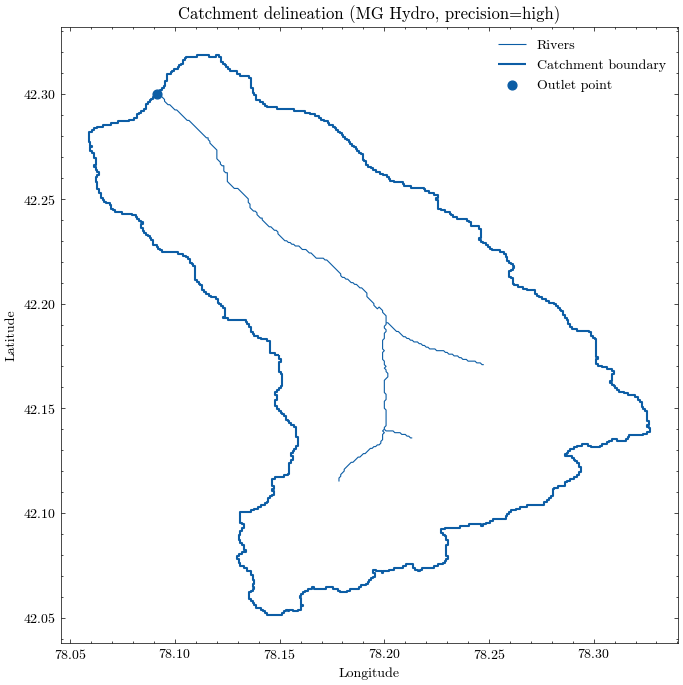

In [2]:
from tools.geetools import delineate_catchment_mghydro

watershed_gdf, rivers_gdf = delineate_catchment_mghydro(
    lat=y,
    lon=x,
    watershed_output_path=catchment_file,
    rivers_output_path=rivers_file,
    fallback_to_local=True,
    precision=mghydro_precision,
    plot=True,
)

The delineated catchment is now stored locally and can be inspected like any other vector dataset. We also derive the catchment area and the bounding box, which will be useful for the following download steps.

In [3]:
catchment_area_km2 = watershed_gdf.to_crs(watershed_gdf.estimate_utm_crs()).area.iloc[0] / 1e6
xmin, ymin, xmax, ymax = watershed_gdf.total_bounds

print(f'Catchment area: {catchment_area_km2:.2f} km²')
print(f'Catchment bounds: xmin={xmin:.5f}, ymin={ymin:.5f}, xmax={xmax:.5f}, ymax={ymax:.5f}')

Catchment area: 302.68 km²
Catchment bounds: xmin=78.05875, ymin=42.05125, xmax=78.32708, ymax=42.31875


## Download the digital elevation model (DEM)

Now that we have the catchment boundaries, we can send a precise request to the MATILDA web service to download a DEM. The default is the [MERIT DEM](https://developers.google.com/earth-engine/datasets/catalog/MERIT_DEM_v1_0_3), but you can use any of the alternatives listed in the `config.ini` file.

In [4]:
from tools.geetools import download_dem_webservice

download_dem_webservice(
    geometry=watershed_gdf,
    asset_id=dem_config[1],
    output_path=filename
)

✅ DEM successfully downloaded from the MATILDA web service.
Saved to: output/dem_gee.tif
File size: 0.4 MB
Elapsed time: 3.4 s


We will now plot the downloaded elevation model alongside the delineated catchment boundary, the upstream river network, and the outlet point.

This visual check helps confirm that:

 - the downloaded DEM covers the full catchment,
 - the watershed boundary is plausible,
 - the outlet point is correctly located, and
 - the river network matches the topographic setting.

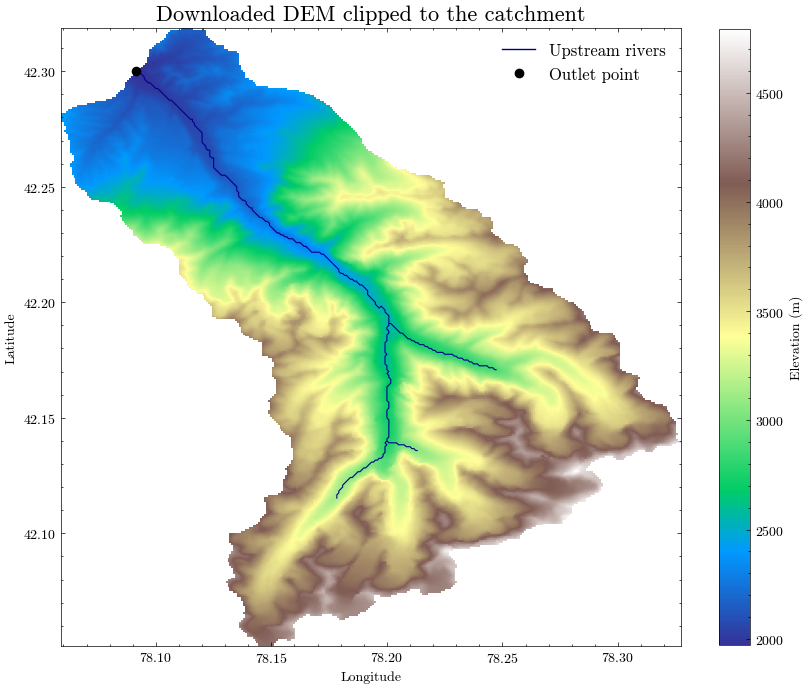

In [5]:
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from matplotlib.lines import Line2D
import geopandas as gpd
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))

with rasterio.open(filename) as src:
    watershed_plot = watershed_gdf.to_crs(src.crs)
    rivers_plot = rivers_gdf.to_crs(src.crs)

    outlet_gdf = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy([x], [y]),
        crs="EPSG:4326"
    ).to_crs(src.crs)

    dem_clip, dem_transform = mask(src, watershed_plot.geometry, crop=True)

    dem_plot = dem_clip[0].astype(float)
    if src.nodata is not None:
        dem_plot[dem_plot == src.nodata] = np.nan
    else:
        dem_plot[dem_plot == 0] = np.nan

    dem_image = show(dem_plot, transform=dem_transform, ax=ax, cmap="terrain")

if not rivers_plot.empty:
    rivers_plot.plot(ax=ax, linewidth=0.8, color="darkblue", zorder=2)

outlet_gdf.plot(ax=ax, color="black", markersize=35, zorder=3)

legend_elements = [
    Line2D([0], [0], color="darkblue", lw=1.0, label="Upstream rivers"),
    Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=6, label="Outlet point"),
]

ax.legend(handles=legend_elements, fontsize=12)
ax.set_title("Downloaded DEM clipped to the catchment", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

cbar = plt.colorbar(dem_image.get_images()[0], ax=ax, shrink=0.8)
cbar.set_label("Elevation (m)")

plt.show()

For the following steps, we store the delineated catchment outline in a **GeoPackage** together with the elevation data derived from the DEM.

We also calculate basic elevation statistics from the clipped DEM:

- minimum elevation
- maximum elevation
- mean catchment elevation

These statistics will later be used for the glacio-hydrological model setup in Notebook 4.

In [6]:
import numpy as np

# Save catchment polygon to GeoPackage
layer_name = "catchment_orig"

watershed_gdf.to_file(
    output_gpkg,
    layer=layer_name,
    driver="GPKG"
)

print(f"Layer '{layer_name}' added to GeoPackage '{output_gpkg}'\n")

# Calculate elevation statistics from clipped DEM
dem_values = dem_plot[~np.isnan(dem_plot)]

ele_min = float(np.min(dem_values))
ele_max = float(np.max(dem_values))
ele_mean = float(np.mean(dem_values))


print(f"Catchment elevation ranges from {ele_min:.0f} m to {ele_max:.0f} m a.s.l.")
print(f"Mean catchment elevation is {ele_mean:.2f} m a.s.l.")

Layer 'catchment_orig' added to GeoPackage 'output/catchment_data.gpkg'

Catchment elevation ranges from 1972 m to 4792 m a.s.l.
Mean catchment elevation is 3273.10 m a.s.l.


## Determine glaciers in catchment area

To acquire outlines of all glaciers in the catchment we will use the Randolph Glacier Inventory version 6 (RGI 6.0). *While RGI version 7 has been released, there are no fully compatible ice thickness datasets yet.*

> The *Randolph Glacier Inventory* is a global inventory of glacier outlines. It is supplemental to the Global Land Ice Measurements from Space initiative (GLIMS). Production of the RGI was motivated by the Fifth Assessment Report of the Intergovernmental Panel on Climate Change (IPCC AR5).
>
> Source: https://www.glims.org/RGI/

The RGI dataset is divided into 19 so called *first-order regions*.

> RGI regions were developed under only three constraints: that they should resemble commonly recognized glacier domains, that together they should contain all of the world’s glaciers, and that their boundaries should be simple and readily recognizable on a map of the world.
>
> Source: [Pfeffer et.al. 2014](https://doi.org/10.3189/2014jog13j176)

![Map of the RGI regions; the red dots indicate the glacier locations and the blue circles the location of the 254 reference WGMS glaciers used by the OGGM calibration](https://docs.oggm.org/en/v1.2.0/_images/wgms_rgi_map.png)

In the first step, the RGI region of the catchment area must be determined to access the correct repository. Therefore, the RGI region outlines will be downloaded and joined with the catchment outline.

> Source: [RGI Consortium (2017)](https://doi.org/10.7265/4m1f-gd79)

In [7]:
import geopandas as gpd

# load catchment and RGI regions as DF
catchment = gpd.read_file(output_gpkg, layer='catchment_orig')
df_regions = gpd.read_file('https://www.gtn-g.ch/database/GlacReg_2017.zip', layer='GTN-G_glacier_regions_201707')
display(df_regions)

,FULL_NAME,RGI_CODE,WGMS_CODE,geometry
0,Alaska,1,ALA,"POLYGON ((-133 54.5, -134 54.5, -134 54, -134 ..."
1,Alaska,1,ALA,"POLYGON ((180 50, 179 50, 178 50, 177 50, 176 ..."
2,Western Canada and USA,2,WNA,"POLYGON ((-133 54.5, -132 54.5, -131 54.5, -13..."
3,"Arctic Canada, North",3,ACN,"POLYGON ((-125 74, -125 75, -125 76, -125 77, ..."
4,"Arctic Canada, South",4,ACS,"POLYGON ((-90 74, -89 74, -88 74, -87 74, -86 ..."
5,Greenland Periphery,5,GRL,"POLYGON ((-75 77, -74.73 77.51, -74.28 78.06, ..."
6,Iceland,6,ISL,"POLYGON ((-26 59, -26 60, -26 61, -26 62, -26 ..."
7,Svalbard and Jan Mayen,7,SJM,"POLYGON ((-10 70, -10 71, -10 72, -10 73, -10 ..."
8,Scandinavia,8,SCA,"POLYGON ((4 70, 4 71, 4 72, 4 73, 4 74, 5 74, ..."
9,Russian Arctic,9,RUA,"POLYGON ((35 70, 35 71, 35 72, 35 73, 35 74, 3..."


For spatial calculations it is crucial to use the correct projection. To avoid inaccuracies due to unit conversions we will project the data to UTM whenever we calculate spatial statistics. The relevant UTM zone and band for the catchment area are determined from the coordinates of the pouring point.

In [8]:
import utm
from pyproj import CRS

utm_zone = utm.from_latlon(y, x)
print(f"UTM zone '{utm_zone[2]}', band '{utm_zone[3]}'")

# get CRS based on UTM
crs = CRS.from_dict({'proj': 'utm', 'zone': utm_zone[2], 'south': False})

catchment_area = catchment.to_crs(crs).area[0] / 1000 / 1000
print(f"Catchment area (projected) is {catchment_area:.2f} km²")

UTM zone '44', band 'T'
Catchment area (projected) is 302.68 km²


Now we can perform a spatial join between the catchment outline and the RGI regions. If the catchment contains any glaciers, the corresponding RGI region is determined in this step.

In [9]:
df_regions = df_regions.set_crs('EPSG:4326', allow_override=True)
catchment = catchment.to_crs('EPSG:4326')
df_regions_catchment = gpd.sjoin(df_regions, catchment, how="inner", predicate="intersects")

if len(df_regions_catchment.index) == 0:
    print('No area found for catchment')
    rgi_region = None
elif len(df_regions_catchment.index) == 1:
    rgi_region = df_regions_catchment.iloc[0]['RGI_CODE']
    print(f"Catchment belongs to RGI region {rgi_region} ({df_regions_catchment.iloc[0]['FULL_NAME']})")
else:
    print("Catchment belongs to more than one region. This use case is not yet supported.")
    display(df_regions_catchment)
    rgi_region = None
rgi_code = int(df_regions_catchment['RGI_CODE'].iloc[0])

Catchment belongs to RGI region 13 (Asia, Central)


In the next step, the glacier outlines for the determined RGI region will be downloaded. First, we access the repository...

In [10]:
from resourcespace import ResourceSpace
from tools.geetools import load_webservice_config
import pandas as pd

# use guest credentials to access media server
hu_cfg = load_webservice_config(section="HU")

api_base_url = hu_cfg["MEDIA_API_URL"]
private_key = hu_cfg["MEDIA_PRIVATE_KEY"]
user = hu_cfg["MEDIA_USER"]

myrepository = ResourceSpace(api_base_url, user, private_key)

print("Accessed remote repository")

# get resource IDs for each .zip file
rgi_refs = pd.DataFrame(myrepository.get_collection_resources(1168))[
    ['ref', 'file_size', 'file_extension', 'field8']]

if not rgi_refs.empty:
    print("Listing files ...")
    display(rgi_refs)
else:
    print("No files found. Please check remote repository.")

Accessed remote repository
Listing files ...


,ref,file_size,file_extension,field8
0,27366,1588336,zip,rgi60_regions
1,27350,11343491,zip,rgi60_03
2,27351,2513426,zip,rgi60_06
3,27354,4525438,zip,rgi60_08
4,27362,25220396,zip,rgi60_17
5,27363,46424343,zip,rgi60_14
6,27369,65663035,zip,rgi60_13
7,27364,78735223,zip,rgi60_05
8,27359,5838874,zip,rgi60_11
9,27368,15050599,zip,rgi60_19


...and download the `.shp` files for the target region.

In [11]:
%%time

import os
import io
from zipfile import ZipFile

output_dir = os.path.join(output_folder, 'RGI')
os.makedirs(output_dir, exist_ok=True)

cnt_rgi = 0
file_names_rgi = []

region_code_str = f'rgi60_{rgi_code:02d}'
#filtering the .zip archives to match our catchment area
filtered_refs = rgi_refs[rgi_refs['field8'] == region_code_str]

if filtered_refs.empty:
    print(f'No RGI archive found for region {rgi_code}')
else:
    print(f'Found RGI archive(s) for region {rgi_code}:')
    display(filtered_refs)

# extracting files from the .zip archives
    for _, row in filtered_refs.iterrows():
        content = myrepository.get_resource_file(row['ref'], row['file_extension'])
        with ZipFile(io.BytesIO(content), 'r') as zipObj:
            zipObj.extractall(output_dir)
            extracted = zipObj.namelist()
            file_names_rgi.extend(extracted)
            cnt_rgi += len(extracted)

    print(f'{cnt_rgi} files extracted to: {output_dir}')

#reading the shapefile
import glob

region_str = f"{rgi_code}_rgi60_*.shp"
search_pattern = os.path.join(output_folder, 'RGI', region_str)

matching_files = glob.glob(search_pattern)

if matching_files:
    rgi_path = matching_files[0]
    rgi = gpd.read_file(rgi_path)
    print(f"Loaded: {rgi_path}")
else:
    print(f"no shapefile for {rgi_code} found")

Found RGI archive(s) for region 13:


,ref,file_size,file_extension,field8
6,27369,65663035,zip,rgi60_13


5 files extracted to: output/RGI
Loaded: output/RGI/13_rgi60_CentralAsia.shp
CPU times: user 1.47 s, sys: 389 ms, total: 1.86 s
Wall time: 9.6 s


Now we can perform a spatial join to determine all glacier outlines that intersect with the catchment area.

In [12]:
if rgi.crs != catchment.crs:
    print("CRS adjusted")
    catchment = catchment.to_crs(rgi.crs)

# check whether catchment intersects with glaciers of region
print('Perform spatial join...')
rgi_catchment = gpd.sjoin(rgi, catchment, how='inner', predicate='intersects')
if len(rgi_catchment.index) > 0:
    print(f'{len(rgi_catchment.index)} outlines loaded from RGI Region {rgi_code}\n')

Perform spatial join...
51 outlines loaded from RGI Region 13



Some glaciers are not actually in the catchment, but intersect its outline due to spatial inaccuracies. We will first determine their fractional overlap with the target catchment.

In [13]:
# calculate percentage of each glacier area that lies within the catchment
rgi_catchment['rgi_area'] = rgi_catchment.to_crs(crs).area

gdf_joined = gpd.overlay(catchment, rgi_catchment, how='intersection')
gdf_joined['area_joined'] = gdf_joined.to_crs(crs).area
gdf_joined['share_of_area'] = round((gdf_joined['area_joined'] / gdf_joined['rgi_area'] * 100), 2)

results = (gdf_joined
           .groupby('RGIId', as_index=False)
           .agg({'share_of_area': 'sum'}))

display(results.sort_values('share_of_area', ascending=False))

,RGIId,share_of_area
25,RGI60-13.06378,100.00
43,RGI60-13.07718,100.00
28,RGI60-13.06381,100.00
27,RGI60-13.06380,100.00
26,RGI60-13.06379,100.00
24,RGI60-13.06377,100.00
23,RGI60-13.06376,100.00
22,RGI60-13.06375,100.00
21,RGI60-13.06374,100.00
20,RGI60-13.06373,100.00


Now we can **filter** based on the percentage of shared area. After that the catchment area will be adjusted as follows:

- **&#8805;50%** of the area are in the catchment &rarr; **include** and extend catchment area by full glacier outlines (if needed)
- **<50%** of the area are in the catchment &rarr; **exclude** and reduce catchment area by glacier outlines (if needed)

In [14]:
rgi_catchment_merge = pd.merge(rgi_catchment, results, on="RGIId")
rgi_in_catchment = rgi_catchment_merge.loc[rgi_catchment_merge['share_of_area'] >= 50]
rgi_out_catchment = rgi_catchment_merge.loc[rgi_catchment_merge['share_of_area'] < 50]

catchment_new = gpd.overlay(catchment, rgi_out_catchment, how='difference')
catchment_new = gpd.overlay(catchment_new, rgi_in_catchment, how='union')
catchment_new = catchment_new.dissolve().reset_index(drop=True)
catchment_new["LABEL"] = 1
catchment_new = catchment_new[["LABEL", "geometry"]]

print(f'Total number of determined glacier outlines: {len(rgi_catchment_merge)}')
print(f'Number of included glacier outlines (overlap >= 50%): {len(rgi_in_catchment)}')
print(f'Number of excluded glacier outlines (overlap < 50%): {len(rgi_out_catchment)}')

Total number of determined glacier outlines: 51
Number of included glacier outlines (overlap >= 50%): 38
Number of excluded glacier outlines (overlap < 50%): 13


The RGI-IDs of the remaining glaciers are stored in `Glaciers_in_catchment.csv`.

In [15]:
from pathlib import Path

Path(output_folder + 'RGI').mkdir(parents=True, exist_ok=True)

glacier_ids = pd.DataFrame(rgi_in_catchment)
glacier_ids['RGIId'] = glacier_ids['RGIId'].map(lambda x: str(x).lstrip('RGI60-'))
glacier_ids.to_csv(output_folder + 'RGI/' + 'Glaciers_in_catchment.csv', columns=['RGIId', 'GLIMSId'], index=False)
display(glacier_ids)

,RGIId,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmin,...,Surging,Linkages,Name,geometry,index_right,area_km2,outlet_lat,outlet_lng,rgi_area,share_of_area
0,13.06353,G078245E42230N,20020825,-9999999,78.245360,42.230246,13,3,0.122,3827,...,9,9,None,"POLYGON ((78.2473 42.22858, 78.24725 42.22858,...",0,303,42.3,78.091,1.224364e+05,78.82
1,13.06354,G078260E42217N,20020825,-9999999,78.259558,42.216524,13,3,0.269,3788,...,9,9,None,"POLYGON ((78.25962 42.21159, 78.25962 42.21161...",0,303,42.3,78.091,2.689387e+05,72.91
2,13.06355,G078253E42212N,20020825,-9999999,78.252936,42.211929,13,3,0.177,3640,...,9,9,None,"POLYGON ((78.25481 42.2114, 78.25437 42.21124,...",0,303,42.3,78.091,1.772685e+05,100.00
3,13.06356,G078242E42208N,20020825,-9999999,78.241914,42.207501,13,3,0.397,3665,...,9,9,None,"POLYGON ((78.24325 42.20383, 78.24278 42.20365...",0,303,42.3,78.091,3.976880e+05,100.00
4,13.06357,G078259E42209N,20020825,-9999999,78.258704,42.209002,13,3,0.053,3870,...,9,9,None,"POLYGON ((78.2596 42.20812, 78.25958 42.20812,...",0,303,42.3,78.091,5.305518e+04,100.00
5,13.06358,G078286E42186N,20020825,-9999999,78.285595,42.185778,13,3,0.082,3893,...,9,9,None,"POLYGON ((78.28462 42.18393, 78.28461 42.18394...",0,303,42.3,78.091,8.178833e+04,100.00
6,13.06359,G078305E42146N,20020825,-9999999,78.304754,42.146142,13,3,4.201,3362,...,9,1,Karabatkak Glacier,"POLYGON ((78.30373 42.14478, 78.30374 42.1449,...",0,303,42.3,78.091,4.202605e+06,99.76
7,13.06360,G078285E42147N,20020825,-9999999,78.284766,42.146579,13,3,0.253,3689,...,9,9,None,"POLYGON ((78.2866 42.14613, 78.2866 42.14613, ...",0,303,42.3,78.091,2.530299e+05,100.00
8,13.06361,G078273E42140N,20020825,-9999999,78.272803,42.140310,13,3,2.046,3328,...,9,9,None,"POLYGON ((78.27549 42.13342, 78.27502 42.13358...",0,303,42.3,78.091,2.047230e+06,100.00
9,13.06362,G078260E42141N,20020825,-9999999,78.260391,42.140731,13,3,0.140,3912,...,9,9,None,"POLYGON ((78.25779 42.1406, 78.25783 42.14063,...",0,303,42.3,78.091,1.402120e+05,100.00


With the updated catchment outline we can now determine the **final area of the catchment** and the **part covered by glaciers**.

In [16]:
catchment_new['area'] = catchment_new.to_crs(crs)['geometry'].area
area_glac = rgi_in_catchment.to_crs(crs)['geometry'].area

area_glac = area_glac.sum() / 1000000
area_cat = catchment_new.iloc[0]['area'] / 1000000
cat_cent = catchment_new.to_crs(crs).centroid
lat = cat_cent.to_crs('EPSG:4326').y[0]

print(f"New catchment area is {area_cat:.2f} km²")
print(f"Glacierized catchment area is {area_glac:.2f} km²")

New catchment area is 301.77 km²
Glacierized catchment area is 31.83 km²


The files just created are added to the existing geopackage...

In [17]:
rgi_in_catchment.to_file(output_gpkg, layer='rgi_in', driver='GPKG')
print(f"Layer 'rgi_in' added to GeoPackage '{output_gpkg}'")

rgi_out_catchment.to_file(output_gpkg, layer='rgi_out', driver='GPKG')
print(f"Layer 'rgi_out' added to GeoPackage '{output_gpkg}'")

catchment_new.to_file(output_gpkg, layer='catchment_new', driver='GPKG')
print(f"Layer 'catchment_new' added to GeoPackage '{output_gpkg}'")

Layer 'rgi_in' added to GeoPackage 'output/catchment_data.gpkg'
Layer 'rgi_out' added to GeoPackage 'output/catchment_data.gpkg'
Layer 'catchment_new' added to GeoPackage 'output/catchment_data.gpkg'


... and can be combined in a simple plot.

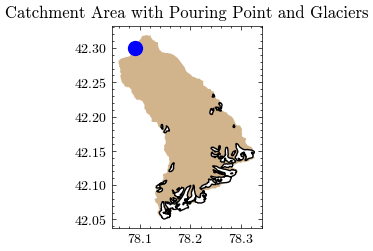

In [18]:
fig, ax = plt.subplots()
catchment_new.plot(color='tan', ax=ax)
rgi_in_catchment.plot(color="white", edgecolor="black", ax=ax)
plt.scatter(x, y, facecolor='blue', s=100)
plt.title("Catchment Area with Pouring Point and Glaciers")
plt.savefig(figures_folder + 'NB1_Glaciers_Catchment.png')
plt.show()

After adding the new catchment area to GEE, we can easily calculate the mean catchment elevation in meters above sea level.

In [19]:
from tools.helpers import mean_elevation_from_raster

ele_cat = mean_elevation_from_raster(filename, catchment_new)
print(f"Mean catchment elevation (adjusted) is {ele_cat:.2f} m a.s.l.")

Mean catchment elevation (adjusted) is 3268.99 m a.s.l.


### Interim Summary:

So far we have...

- ...delineated the catchment and determined its area,

- ...calculated the average elevation of the catchment,

- ...identified the glaciers in the catchment and calculated their combined area.

In the next step, we will create a glacier profile to determine how the ice is distributed over the elevation range.
___

## Retrieve ice thickness rasters and corresponding DEM files

Determining ice thickness from remotely sensed data is a challenging task. Fortunately, [Farinotti et.al. (2019)](https://doi.org/10.1038/s41561-019-0300-3) calculated an ensemble estimate of different methods for all glaciers in RGI6 and made the data available [to the public](https://www.research-collection.ethz.ch/handle/20.500.11850/315707).

The published repository contains...

> (a) the **ice thickness distribution** of individual glaciers,<br/>
> (b) global grids at various resolutions with **summary-information about glacier number, area, and volume**, and<br/>
> (c) the **digital elevation models** of the glacier surfaces used to produce the estimates.
>
> Nomenclature for glaciers and regions follows the Randolph Glacier Inventory (RGI) version 6.0.
>
> Source: Farinotti et.al. 2019 - [README](https://www.research-collection.ethz.ch/bitstream/handle/20.500.11850/315707/README.txt)

The **ice thickness rasters (a)** and **aligned DEMs (c)** are the perfect input data for our glacier profile. The files are selected and downloaded by their **RGI IDs** and stored in the output folder.

Since the original files hosted by ETH Zurich are stored in large archives, we cut the dataset into smaller slices and reupload them according to the respective [license](https://creativecommons.org/licenses/by-nc-sa/4.0/) to make them searchable, improve performance, and limit traffic.

First, we identify the relevant archives for our set of glacier IDs.

In [20]:
def getArchiveNames(row):
    region = row['RGIId'].split('.')[0]
    id = (int(row['RGIId'].split('.')[1]) - 1) // 1000 + 1
    return f'ice_thickness_{region}_{id}', f'dem_surface_DEM_{region}_{id}'


# determine relevant .zip files for derived RGI IDs
df_rgiids = pd.DataFrame(rgi_in_catchment['RGIId'].sort_values())
df_rgiids[['thickness', 'dem']] = df_rgiids.apply(getArchiveNames, axis=1, result_type='expand')
zips_thickness = df_rgiids['thickness'].drop_duplicates()
zips_dem = df_rgiids['dem'].drop_duplicates()

print(f'Thickness archives:\t{zips_thickness.tolist()}')
print(f'DEM archives:\t\t{zips_dem.tolist()}')

Thickness archives:	['ice_thickness_RGI60-13_7', 'ice_thickness_RGI60-13_8']
DEM archives:		['dem_surface_DEM_RGI60-13_7', 'dem_surface_DEM_RGI60-13_8']


The archives are stored on a file server at the Humboldt University of Berlin, which provides limited read access to this notebook. The corresponding credentials and API key are defined in the `config.ini` file. The next step is to identify the corresponding resource references for the previously identified archives.

In [21]:
from resourcespace import ResourceSpace
from tools.geetools import load_webservice_config

# use guest credentials to access media server
hu_cfg = load_webservice_config(section="HU")

api_base_url = hu_cfg["MEDIA_API_URL"]
private_key = hu_cfg["MEDIA_PRIVATE_KEY"]
user = hu_cfg["MEDIA_USER"]

myrepository = ResourceSpace(api_base_url, user, private_key)

# get resource IDs for each .zip file
refs_thickness = pd.DataFrame(myrepository.get_collection_resources(12))[
    ['ref', 'file_size', 'file_extension', 'field8']
]
refs_dem = pd.DataFrame(myrepository.get_collection_resources(21))[
    ['ref', 'file_size', 'file_extension', 'field8']
]

# reduce list of resources to the required zip files
refs_thickness = pd.merge(zips_thickness, refs_thickness, left_on='thickness', right_on='field8')
refs_dem = pd.merge(zips_dem, refs_dem, left_on='dem', right_on='field8')

print('Thickness archive references:\n')
display(refs_thickness)
print('DEM archive references:\n')
display(refs_dem)

Thickness archive references:



,thickness,ref,file_size,file_extension,field8
0,ice_thickness_RGI60-13_7,26948,4397086,zip,ice_thickness_RGI60-13_7
1,ice_thickness_RGI60-13_8,26986,5380873,zip,ice_thickness_RGI60-13_8


DEM archive references:



,dem,ref,file_size,file_extension,field8
0,dem_surface_DEM_RGI60-13_7,27206,8669226,zip,dem_surface_DEM_RGI60-13_7
1,dem_surface_DEM_RGI60-13_8,27187,11160282,zip,dem_surface_DEM_RGI60-13_8


Again, depending on the number of files and bandwidth, this may take a moment. Let's start with the **ice thickness**...

In [22]:
%%time

import requests
from zipfile import ZipFile
import io

cnt_thickness = 0
file_names_thickness = []
for idx, row in refs_thickness.iterrows():
    content = myrepository.get_resource_file(row['ref'], row['file_extension'])
    with ZipFile(io.BytesIO(content), 'r') as zipObj:
        # Get a list of all archived file names from the zip
        listOfFileNames = zipObj.namelist()
        for rgiid in df_rgiids.loc[df_rgiids['thickness'] == row['field8']]['RGIId']:
            filename = rgiid + '_thickness.tif'
            if filename in listOfFileNames:
                cnt_thickness += 1
                zipObj.extract(filename, output_folder + 'RGI')
                file_names_thickness.append(filename)
            else:
                print(f'File not found: {filename}')

print(f'{cnt_thickness} files have been extracted (ice thickness)')

38 files have been extracted (ice thickness)
CPU times: user 114 ms, sys: 20 ms, total: 134 ms
Wall time: 1.77 s


...and continue with the matching **DEMs**.

In [23]:
%%time

cnt_dem = 0
file_names_dem = []
for idx, row in refs_dem.iterrows():
    content = myrepository.get_resource_file(row['ref'])
    with ZipFile(io.BytesIO(content), 'r') as zipObj:
        # Get a list of all archived file names from the zip
        listOfFileNames = zipObj.namelist()
        for rgiid in df_rgiids.loc[df_rgiids['dem'] == row['field8']]['RGIId']:
            filename = f"surface_DEM_{rgiid}.tif"
            if filename in listOfFileNames:
                cnt_dem += 1
                zipObj.extract(filename, output_folder + 'RGI')
                file_names_dem.append(filename)
            else:
                print(f'File not found: {filename}')

print(f'{cnt_dem} files have been extracted (DEM)')

38 files have been extracted (DEM)
CPU times: user 148 ms, sys: 27 ms, total: 175 ms
Wall time: 2.38 s


<div class="alert alert-block alert-warning">
<b>Note:</b>
 Please check whether all files have been extracted to the output folder without error messages and <b>the number of files matches the number of glaciers</b>.</div>

In [24]:
if len(rgi_in_catchment) == cnt_thickness == cnt_dem:
    print(f"Number of files matches the number of glaciers within catchment: {len(rgi_in_catchment)}")
else:
    print("There is a mismatch of extracted files. Please check previous steps for error messages!")
    print(f'Number of included glaciers:\t{len(rgi_in_catchment)}')
    print(f'Ice thickness files:\t\t{cnt_thickness}')
    print(f'DEM files:\t\t\t{cnt_dem}')

Number of files matches the number of glaciers within catchment: 38


## Glacier profile creation

The **glacier profile** is used to pass the distribution of ice mass in the catchment to the glacio-hydrological model in **Notebook 4**, following the approach of [Seibert et.al.2018](https://doi.org/10.5194/hess-22-2211-2018). The model then calculates the annual mass balance and redistributes the ice mass accordingly.

To derive the profile from spatially distributed data, we first stack the ice thickness and corresponding DEM rasters for each glacier and create tuples of ice thickness and elevation values.

In [25]:
from osgeo import gdal
gdal.UseExceptions()

df_all = pd.DataFrame()
if cnt_thickness != cnt_dem:
    print('Number of ice thickness raster files does not match number of DEM raster files!')
else:
    for idx, rgiid in enumerate(df_rgiids['RGIId']):
        if rgiid in file_names_thickness[idx] and rgiid in file_names_dem[idx]:
            file_list = [
                output_folder + 'RGI/' + file_names_thickness[idx],
                output_folder + 'RGI/' + file_names_dem[idx]
            ]
            array_list = []

            # Read arrays
            for file in file_list:
                src = gdal.Open(file)
                geotransform = src.GetGeoTransform()
                projection = src.GetProjectionRef()
                array_list.append(src.ReadAsArray())
                pixelSizeX = geotransform[1]
                pixelSizeY = -geotransform[5]
                src = None

            df = pd.DataFrame()
            df['thickness'] = array_list[0].flatten()
            df['altitude'] = array_list[1].flatten()
            df_all = pd.concat([df_all, df])

        else:
            print(f'Raster files do not match for {rgiid}')

print("Ice thickness and elevations rasters stacked")
print("Value pairs created")

Ice thickness and elevations rasters stacked
Value pairs created


Now we can remove all data points with zero ice thickness and aggregate all data points into 10m **elevation zones**. The next step is to calculate the **water equivalent** (WE) from the average ice thickness in each elevation zone.

The result is exported to the output folder as `glacier_profile.csv`.

In [26]:
if len(df_all) > 0:
    df_all = df_all.loc[df_all['thickness'] > 0]
    df_all.sort_values(by=['altitude'], inplace=True)

    # get min/max altitude considering catchment and all glaciers
    alt_min = 10 * int(min(ele_min, df_all['altitude'].min()) / 10)
    alt_max = max(ele_max, df_all['altitude'].max()) + 10

    # create bins in 10 m steps
    bins = np.arange(alt_min, df_all['altitude'].max() + 10, 10)

    # aggregate per bin and do some math
    df_agg = (
    df_all.groupby(pd.cut(df_all['altitude'], bins), observed=False)['thickness']
    .agg(count='size', mean='mean')
    .reset_index()
    )
    df_agg['Elevation'] = df_agg['altitude'].apply(lambda x: x.left).astype(int)
    df_agg['Area'] = df_agg['count'] * pixelSizeX * pixelSizeY / catchment_new.iloc[0]['area']
    df_agg['WE'] = df_agg['mean'] * 0.908 * 1000
    df_agg['EleZone'] = df_agg['Elevation'].apply(lambda x: 100 * int(x / 100))

    # delete empty elevation bands but keep at least one entry per elevation zone
    df_agg = pd.concat([
        df_agg.loc[df_agg['count'] > 0],
        df_agg.loc[df_agg['count'] == 0].drop_duplicates(['EleZone'], keep='first')
    ]).sort_index()

    df_agg.drop(['altitude', 'count', 'mean'], axis=1, inplace=True)
    df_agg = df_agg.replace(np.nan, 0)
    df_agg.to_csv(output_folder + 'glacier_profile.csv', header=True, index=False)
    print('Glacier profile for catchment created!\n')
    display(df_agg)

Glacier profile for catchment created!



,Elevation,Area,WE,EleZone
0,1970,0.000000,0.000000,1900
3,2000,0.000000,0.000000,2000
13,2100,0.000000,0.000000,2100
23,2200,0.000000,0.000000,2200
33,2300,0.000000,0.000000,2300
...,...,...,...,...
276,4730,0.000023,20721.369141,4700
277,4740,0.000012,14450.217773,4700
278,4750,0.000006,10551.472656,4700
279,4760,0.000000,0.000000,4700


Let's visualize the glacier profile. First we aggregate the ice mass in larger elevation zones for better visibility. The level of aggregation can be adjusted using the variable `steps` (default is 20m).

In [27]:
# aggregation level for plot -> feel free to adjust
steps = 20

# get elevation range where glaciers are present
we_range = df_agg.loc[df_agg['WE'] > 0]['Elevation']
we_range.min() // steps * steps
plt_zones = pd.Series(range(int(we_range.min() // steps * steps),
                            int(we_range.max() // steps * steps + steps),
                            steps), name='EleZone').to_frame().set_index('EleZone')

# calculate glacier mass and aggregate glacier profile to defined elevation steps
plt_data = df_agg.copy()
plt_data['EleZone'] = plt_data['Elevation'].apply(lambda x: int(x // steps * steps))
plt_data['Mass'] = plt_data['Area'] * catchment_new.iloc[0]['area'] * plt_data['WE'] * 1e-9  # mass in Mt
plt_data = plt_data.drop(['Area', 'WE'], axis=1).groupby('EleZone').sum().reset_index().set_index('EleZone')
plt_data = plt_zones.join(plt_data)
display(plt_data)

,Elevation,Mass
EleZone,,
3320,6650,0.061096
3340,6690,0.485334
3360,6730,1.311347
3380,6770,2.808075
3400,6810,5.413687
...,...,...
4700,9410,0.410695
4720,9450,0.402655
4740,9490,0.073972


Now, we can plot the estimated **glacier mass (in Mt) for each elevation zone.**

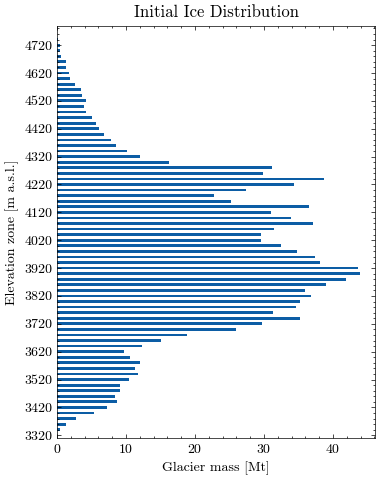

In [28]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(4, 5))
plt_data.plot.barh(y='Mass', ax=ax)
ax.set_xlabel("Glacier mass [Mt]")
ax.set_yticks(ax.get_yticks()[::int(100 / steps)])
ax.set_ylabel("Elevation zone [m a.s.l.]")
ax.get_legend().remove()
plt.title("Initial Ice Distribution")
plt.tight_layout()
plt.savefig(figures_folder + 'NB1_Glacier_Mass_Elevation.png')
plt.show()

Finally, we calculate the average glacier elevation in meters above sea level.

In [29]:
ele_glac = round(df_all.altitude.mean(), 2)
print(f'Average glacier elevation in the catchment: {ele_glac:.2f} m a.s.l.')

Average glacier elevation in the catchment: 4001.88 m a.s.l.


## Store calculated values for other notebooks

Create a `settings.yml` and store the relevant catchment information for the model setup:

- **area_cat**: area of the catchment in km²
- **ele_cat**: average elevation of the catchment in m.a.s.l.
- **area_glac**: glacier covered area as of 2000 in km²
- **ele_glac**: average elevation of glacier covered area in m.a.s.l.
- **lat**: latitude of catchment centroid

In [30]:
import yaml

settings = {'area_cat': float(area_cat),
            'ele_cat': float(ele_cat),
            'area_glac': float(area_glac),
            'ele_glac': float(ele_glac),
            'lat': float(lat)
            }
with open(output_folder + 'settings.yml', 'w') as f:
    yaml.safe_dump(settings, f)

print('Settings saved to file.')
display(pd.DataFrame(settings.items(), columns=['Parameter', 'Value']).set_index('Parameter'))

Settings saved to file.


,Value
Parameter,
area_cat,301.765549
ele_cat,3268.993340
area_glac,31.829413
ele_glac,4001.879883
lat,42.185418


You can now continue with [Notebook 2](Notebook2_Forcing_data.ipynb) or ...

## *Optional*: Download Outputs

<div class="alert alert-block alert-info">
<b>Note:</b>
 The output folder is zipped at the end of each notebook and can be downloaded (file <code>output_download.zip</code>). This is especially useful if you want to use the binder environment again, but don't want to start over from Notebook 1.</div>

![download](images/download_output.png)

In [31]:
import shutil

if zip_output:
    shutil.make_archive('output_download', 'zip', 'output')
    print('Output folder can be download now (file output_download.zip)')

Output folder can be download now (file output_download.zip)


In [32]:
%reset -f